In [0]:
import pyspark.pandas as ps

In [0]:
path = 'dbfs:/FileStore/tables/arquivo_curso/dados/Spotify_Dataset/dados_tratados/data.parquet'
df_data = ps.read_parquet(path)

# Tratamento de dados

In [0]:
df_data.info()


<class 'pyspark.pandas.frame.DataFrame'>
Int64Index: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int32  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170080 non-null  float64
 5   duration_ms       170454 non-null  int64  
 6   energy            170573 non-null  float64
 7   explicit          170606 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170270 non-null  float64
 10  key               170451 non-null  int64  
 11  liveness          170613 non-null  float64
 12  loudness          170621 non-null  float64
 13  mode              170635 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        169496 non-null  int64  
 16  release_date     

Revomendo os dados Nulos

In [0]:
df_data = df_data.dropna()

In [0]:
df_data.info()

<class 'pyspark.pandas.frame.DataFrame'>
Int64Index: 169300 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           169300 non-null  float64
 1   year              169300 non-null  int32  
 2   acousticness      169300 non-null  float64
 3   artists           169300 non-null  object 
 4   danceability      169300 non-null  float64
 5   duration_ms       169300 non-null  int64  
 6   energy            169300 non-null  float64
 7   explicit          169300 non-null  int64  
 8   id                169300 non-null  object 
 9   instrumentalness  169300 non-null  float64
 10  key               169300 non-null  int64  
 11  liveness          169300 non-null  float64
 12  loudness          169300 non-null  float64
 13  mode              169300 non-null  int64  
 14  name              169300 non-null  object 
 15  popularity        169300 non-null  int64  
 16  release_date     

In [0]:
df_data['artist_song'] = df_data.artists + ' - ' + df_data.name

In [0]:
df_data.head()


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,artist_song
0,0.917,1970,0.096000,The Velvet Underground,0.624,201440,0.774,0,60ZyiL4lmWzZyGfqyECTqp,0.030900,7,0.0960,-10.391,1,Train Round the Bend - 2015 Remaster,24,1970,0.0315,117.006,The Velvet Underground - Train Round the Bend ...
1,0.511,1970,0.001900,Ten Years After,0.405,458463,0.543,0,6DYyyUdHzI6RdSx0swUR1i,0.720000,2,0.1860,-9.313,1,Love Like a Man - 2017 Remaster,34,1970-04-01,0.0290,107.598,Ten Years After - Love Like a Man - 2017 Remaster
2,0.466,1970,0.052800,The Mothers Of Invention,0.444,105587,0.568,0,6HJAS8XZO0ctUcN2KsbLRa,0.000010,11,0.5120,-8.800,0,Oh No,24,1970-08-10,0.0327,124.319,The Mothers Of Invention - Oh No
3,0.523,1970,0.081100,Three Dog Night,0.502,174707,0.669,0,7sZ74qmKb1nyGKUgHROJ1n,0.000945,7,0.0906,-11.725,1,One Man Band,19,1970-01-01,0.0912,121.089,Three Dog Night - One Man Band
4,0.501,1970,0.000128,The Rolling Stones,0.273,246413,0.866,0,095WtNlSHE8TMB2gQ1fdTx,0.790000,11,0.9610,-7.598,1,Street Fighting Man - Live,25,1970-09-04,0.0347,134.891,The Rolling Stones - Street Fighting Man - Live


In [0]:
artista_especifico = 'Oliver Tree'  # Substitua pelo nome do artista que você está procurando
resultado = df_data.filter(df_data.artists == artista_especifico)
print(resultado)

DataFrame[valence: double, year: int, acousticness: double, artists: string, danceability: double, duration_ms: bigint, energy: double, explicit: bigint, id: string, instrumentalness: double, key: bigint, liveness: double, loudness: double, mode: bigint, name: string, popularity: bigint, release_date: string, speechiness: double, tempo: double, artist_song: string]


In [0]:
df_data.info()

<class 'pyspark.pandas.frame.DataFrame'>
Int64Index: 169300 entries, 0 to 170652
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           169300 non-null  float64
 1   year              169300 non-null  int32  
 2   acousticness      169300 non-null  float64
 3   artists           169300 non-null  object 
 4   danceability      169300 non-null  float64
 5   duration_ms       169300 non-null  int64  
 6   energy            169300 non-null  float64
 7   explicit          169300 non-null  int64  
 8   id                169300 non-null  object 
 9   instrumentalness  169300 non-null  float64
 10  key               169300 non-null  int64  
 11  liveness          169300 non-null  float64
 12  loudness          169300 non-null  float64
 13  mode              169300 non-null  int64  
 14  name              169300 non-null  object 
 15  popularity        169300 non-null  int64  
 16  release_date     

Separando todas as variavies disponivel para o ML

In [0]:
X = df_data.columns.to_list()
X.remove('artists')
X.remove('id')
X.remove('name')
X.remove('artist_song')
X.remove('release_date')
X



Out[12]: ['valence',
 'year',
 'acousticness',
 'danceability',
 'duration_ms',
 'energy',
 'explicit',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'mode',
 'popularity',
 'speechiness',
 'tempo']

Convertendo para Spark para conseguir usar a ML Lib

In [0]:
df_data = df_data.to_spark()

# Vetorização

In [0]:
from pyspark.ml.feature import VectorAssembler

In [0]:
dados_encoder_vector = VectorAssembler (inputCols = X, outputCol='features').transform(df_data)

In [0]:
dados_encoder_vector.select('features').show(truncate=False, n=5)

+----------------------------------------------------------------------------------------------------------------------+
|features                                                                                                              |
+----------------------------------------------------------------------------------------------------------------------+
|[0.917,1970.0,0.096,0.624,201440.0,0.774,0.0,0.0309,7.0,0.096,-10.390999999999998,1.0,24.0,0.0315,117.006]            |
|[0.511,1970.0,0.0019,0.405,458463.0,0.5429999999999999,0.0,0.72,2.0,0.18600000000000005,-9.313,1.0,34.0,0.029,107.598]|
|[0.466,1970.0,0.0528,0.444,105587.0,0.568,0.0,1.02E-5,11.0,0.512,-8.8,0.0,24.0,0.0327,124.319]                        |
|[0.523,1970.0,0.0811,0.502,174707.0,0.669,0.0,9.45E-4,7.0,0.0906,-11.725,1.0,19.0,0.0912,121.089]                     |
|[0.501,1970.0,1.28E-4,0.273,246413.0,0.866,0.0,0.79,11.0,0.961,-7.598,1.0,25.0,0.0347,134.891]                        |
+-------------------------------

# Padronização

In [0]:
from pyspark.ml.feature import StandardScaler

In [0]:

# Supondo que você já tenha um DataFrame chamado 'dados_encoded_vector' com a coluna 'features'
scaler = StandardScaler(inputCol='features', outputCol='features_scaled')

# Ajustando o scaler aos dados
model_scaler = scaler.fit(dados_encoder_vector)

# Transformando os dados
dados_musicas_scaler = model_scaler.transform(dados_encoder_vector)

# Visualizando os dados escalados
dados_musicas_scaler.select('features_scaled').show(truncate=False, n=5)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features_scaled                                                                                                                                                                                                                                                               |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[3.493845627581973,76.01945247914719,0.25560097373899326,3.553867728626555,1.6031732036099804,2.8949505209817366,0.0,0.09859458986370954,1.9913197029800866,0.5493560155028588,-1.83

Verificando a quantidade de Features que possuimos


In [0]:
k = len(X)
k

Out[19]: 15

# Tecnica PCA

In [0]:
from pyspark.ml.feature import PCA

In [0]:
pca = PCA(k=k, inputCol='features_scaled', outputCol='pca_features')
model_pca = pca.fit(dados_musicas_scaler)
dados_musicas_pca = model_pca.transform(dados_musicas_scaler)

Funcação PCA onde cada variaves "explica" modelo.  somando todas o resultado deve ser 100%


In [0]:
model_pca.explainedVariance

Out[22]: DenseVector([0.2656, 0.1207, 0.095, 0.0785, 0.0743, 0.0627, 0.0611, 0.0561, 0.05, 0.0418, 0.0342, 0.0227, 0.0203, 0.0089, 0.008])

In [0]:
sum(model_pca.explainedVariance) * 100

Out[23]: 100.00000000000003

Quantos componetes que ue tenho que podem explicar 70% das nossas Features? 

In [0]:
lista_valores = [sum(model_pca.explainedVariance[0:i+1]) for i in range(k)]
lista_valores

Out[24]: [0.26559546201574613,
 0.38633995568156565,
 0.481313066659682,
 0.5598342425313095,
 0.6341616245863154,
 0.6968259227182991,
 0.7579363400230551,
 0.8140504754940465,
 0.8640376949888987,
 0.9058308612627605,
 0.9400513661542073,
 0.9627442126908647,
 0.9830935482319775,
 0.9919540017169323,
 1.0000000000000002]

In [0]:
import numpy as np

In [0]:
k = sum(np.array(lista_valores) <=0.7)
k

Out[26]: 6

In [0]:
pca = PCA(k=k, inputCol='features_scaled', outputCol='pca_features')
model_pca = pca.fit(dados_musicas_scaler)
dados_musicas_pca_final = model_pca.transform(dados_musicas_scaler)

In [0]:
dados_musicas_pca_final.select('pca_features').show(truncate=False, n=5)

+----------------------------------------------------------------------------------------------------------------------+
|pca_features                                                                                                          |
+----------------------------------------------------------------------------------------------------------------------+
|[-32.31725372407879,-18.925010131278484,10.92771429220363,-14.569692108954701,-3.1817403495417502,4.244071962867768]  |
|[-31.132818221782877,-21.34230486564101,12.383759684804449,-13.755472800980986,-3.890295461577214,3.440922089757798]  |
|[-31.78064916266871,-19.569645663588258,12.541114621263855,-12.7857999611422,-1.5971144308353942,4.985715880825078]   |
|[-31.60584489317542,-19.547985862609632,11.833448205764727,-14.450217738392638,-3.5070019153785843,4.9497172630424515]|
|[-31.594059088957664,-20.741768225806418,12.379789932280927,-9.883622640679894,-2.659184406138894,4.54861497646521]   |
+-------------------------------

In [0]:
from pyspark.ml import Pipeline

pca_pipeline = Pipeline(stages=[
    VectorAssembler(inputCols=X, outputCol='features'),
    StandardScaler(inputCol='features', outputCol='features_scaled'),
    PCA(k=6, inputCol='features_scaled', outputCol='pca_features')
])

In [0]:
model_pca_pipeline = pca_pipeline.fit(df_data)

In [0]:
projection = model_pca_pipeline.transform(df_data)

# KMeans Modelo de ML para Clusterização

In [0]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import rand

# Carregando dados de exemplo
data = spark.createDataFrame([(Vectors.dense([0.0, 0.0]),), (Vectors.dense([1.0, 1.0]),),
                              (Vectors.dense([9.0, 8.0]),), (Vectors.dense([8.0, 9.0]),)], ['features']).orderBy(rand())

# Criando o modelo K-means
kmeans = KMeans(k=2, seed=1)
model = kmeans.fit(data)

# Fazendo previsões
predictions = model.transform(data)

# Avaliando a qualidade dos clusters com ClusteringEvaluator
evaluator = ClusteringEvaluator(metricName="silhouette", featuresCol="features", predictionCol="prediction")
silhouette = evaluator.evaluate(predictions)

print(f"Silhouette Score: {silhouette}")


Silhouette Score: 0.9843750073923729


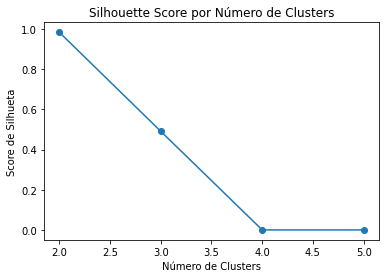

In [0]:
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import rand

# Criando dados de exemplo
data = spark.createDataFrame([
    (Vectors.dense([0.0, 0.0]),), 
    (Vectors.dense([1.0, 1.0]),),
    (Vectors.dense([9.0, 8.0]),), 
    (Vectors.dense([8.0, 9.0]),)
], ['features']).orderBy(rand())

# Avaliando o modelo K-means com diferentes valores de k
silhouette_scores = []
k_values = range(2, 6)

for k in k_values:
    kmeans = KMeans(k=k, seed=1)
    model = kmeans.fit(data)
    
    # Criando previsões
    predictions = model.transform(data)
    
    # Usando ClusteringEvaluator para calcular o Silhouette Score
    evaluator = ClusteringEvaluator(metricName="silhouette", featuresCol="features", predictionCol="prediction")
    silhouette_scores.append(evaluator.evaluate(predictions))

# Plotando o gráfico de Silhouette Score vs Número de Clusters
plt.plot(k_values, silhouette_scores, '-o')
plt.xlabel('Número de Clusters')
plt.ylabel('Score de Silhueta')
plt.title('Silhouette Score por Número de Clusters')
plt.show()


In [0]:
SEED    = 1224

In [0]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=40, featuresCol='pca_features', predictionCol='cluster_pca', seed=SEED)

KMeans: Este é um algoritmo de clustering que agrupa dados em k clusters com base em suas características.

k=50: Define o número de clusters que o algoritmo irá criar. Neste caso, estamos agrupando os dados em 50 clusters. Isso é útil para segmentar os dados em grupos significativos, permitindo uma análise mais fácil e recomendações mais precisas.

featuresCol='pca_features': Especifica a coluna do DataFrame que contém as características (features) a serem usadas para o agrupamento. Aqui, estamos utilizando as pca_features, que são os dados transformados pela técnica de PCA (Análise de Componentes Principais).

predictionCol='cluster_pca': Define o nome da nova coluna que será adicionada ao DataFrame, onde os rótulos dos clusters atribuídos a cada ponto de dados serão armazenados. Neste caso, a coluna se chamará cluster_pca.

seed=SEED: Utiliza uma semente (seed) para garantir a reprodutibilidade dos resultados. Isso significa que, ao executar o algoritmo várias vezes com a mesma semente, você obterá os mesmos clusters, o que é importante para a consistência dos resultados.

In [0]:
modelo_kmeans = kmeans.fit(projection)
projection_kmeans = modelo_kmeans.transform(projection)

In [0]:
projection_kmeans.select('pca_features','cluster_pca').show()

+--------------------+-----------+
|        pca_features|cluster_pca|
+--------------------+-----------+
|[-32.317253724078...|         12|
|[-31.132818221782...|          9|
|[-31.780649162668...|         35|
|[-31.605844893175...|         17|
|[-31.594059088957...|         26|
|[-31.938780024366...|         24|
|[-29.686935486197...|          3|
|[-31.539167346660...|         14|
|[-30.771547827750...|         16|
|[-29.965130076522...|         13|
|[-31.131053018497...|         12|
|[-31.266813769537...|          8|
|[-31.446803723293...|         24|
|[-29.943208559405...|          7|
|[-29.853371939403...|          8|
|[-31.758364291022...|         17|
|[-30.549983241698...|         24|
|[-29.347404415385...|         37|
|[-31.337850883791...|         12|
|[-32.659644073618...|         17|
+--------------------+-----------+
only showing top 20 rows



### Visualizando os dados como esses dados ficou dentro do nosso DF

Para que possamos usar isso em um componente visual 2D precisamos desses valores em um eixo X e Y para isso precisamos converter nosso vetor em dois componetes

In [0]:
    from pyspark.ml.functions import vector_to_array

In [0]:
projection_kmeans = projection_kmeans.withColumn('x', vector_to_array('pca_features')[0])\
                                   .withColumn('y', vector_to_array('pca_features')[1])

In [0]:
projection_kmeans.select('x','y','cluster_pca','artist_song').show()

+-------------------+-------------------+-----------+--------------------+
|                  x|                  y|cluster_pca|         artist_song|
+-------------------+-------------------+-----------+--------------------+
| -32.31725372407879|-18.925010131278484|         12|The Velvet Underg...|
|-31.132818221782877| -21.34230486564101|          9|Ten Years After -...|
| -31.78064916266871|-19.569645663588258|         35|The Mothers Of In...|
| -31.60584489317542|-19.547985862609632|         17|Three Dog Night -...|
|-31.594059088957664|-20.741768225806418|         26|The Rolling Stone...|
|-31.938780024366565| -18.64127655559876|         24|Sly & The Family ...|
|-29.686935486197306| -21.43318756800143|          3|William S. Fische...|
|-31.539167346660424|-20.172532235961633|         14|Yusuf / Cat Steve...|
|-30.771547827750314|-19.778300972177536|         16|The Meters - Oh, ...|
|-29.965130076522186| -20.25008778917281|         13|Linda Ronstadt - ...|
|-31.131053018497823| -19

In [0]:
import plotly.express as px

Como podemos ver visualizar somente esses clustes não ficou tão interessantes.

In [0]:
# espaço pra colcocar o code

## Identificand Cluster

In [0]:
musica_especifica = 'Linkin Park - Numb'  # Escapando o apóstrofo
resultado = df_data.filter(df_data.artist_song == musica_especifica)
print(resultado)

DataFrame[valence: double, year: int, acousticness: double, artists: string, danceability: double, duration_ms: bigint, energy: double, explicit: bigint, id: string, instrumentalness: double, key: bigint, liveness: double, loudness: double, mode: bigint, name: string, popularity: bigint, release_date: string, speechiness: double, tempo: double, artist_song: string]


In [0]:
nome_musica = 'Linkin Park - Numb'  # Escapando o apóstrofo

In [0]:
resultado = projection_kmeans.filter(projection_kmeans.artist_song == nome_musica).select('cluster_pca').collect()

if resultado:
    cluster = resultado[0][0]
else:
    print("Nenhum resultado encontrado para a música:", nome_musica)

Identificamos o Cluster dessa musica agora vamos buscar a lista de musicas recomendadas a partir da musica da Taylo Swuft

In [0]:
musicas_recomendadas = projection_kmeans.filter(projection_kmeans.cluster_pca == cluster)\
                                       .select('artist_song', 'id', 'pca_features')
musicas_recomendadas.show()

+--------------------+--------------------+--------------------+
|         artist_song|                  id|        pca_features|
+--------------------+--------------------+--------------------+
|Erasmo Carlos - D...|3cLVFyJRYkpXVVIgj...|[-32.706778055772...|
|Industria Naciona...|1AXLfboOfuVjS5LwO...|[-32.241174546351...|
|Elton John - When...|73RheFMmYGLht3xAn...|[-32.587164377680...|
|Yol Aularong - Je...|3s1xtTaA36nfLylvv...|[-32.779097173365...|
|Novos Baianos - N...|11gIxacOHnCVPL0dZ...|[-32.669896905160...|
|Roxy Music - If I...|2jXTC9M9kAoHV2IuC...|[-32.573713272083...|
|Ian Hunter - Once...|3j54M5RVFIBFQOIk7...|[-32.767847217302...|
|Funkadelic - Bett...|3Wdrk8eOCEOM1OBK7...|[-32.728221100821...|
|Peter Frampton - ...|5E5cjKPJQIzdFOTd3...|[-32.673889256292...|
|"Johnny ""Guitar"...|5tcrRMV4ibCLHx8s2...|[-32.478784720579...|
|Led Zeppelin - Ca...|1PpSenBXeetCWotWW...|[-32.658162451377...|
|KISS - Then She K...|2B0oanPxauHfMhVyd...|[-33.073056694952...|
|KISS - Tomorrow A...|4Uw

In [0]:
componenetes_musica = musicas_recomendadas.filter(musicas_recomendadas.artist_song == nome_musica)\
                                          .select('pca_features').collect()[0][0]
componenetes_musica

Out[58]: DenseVector([-33.6727, -20.0522, 12.1135, -15.6564, -3.8549, 3.5919])

Agora precisamos encontrar a menor distancia entre a musica sugerida e a distancia dos Clusters.


## Distância Euclidiana

A distância euclidiana é a medida mais comum de distância entre dois pontos em um espaço n-dimensional. Ela é calculada usando o teorema de Pitágoras e representa a "linha reta" entre dois pontos. Em um espaço bidimensional, a distância euclidiana entre os pontos \(A(x_1, y_1)\) e \(B(x_2, y_2)\) é dada pela fórmula:

\[ d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} \]

Em um espaço de múltiplas dimensões, a fórmula se generaliza para:

\[ d(A, B) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2} \]

## Distância de Manhattan

A distância de Manhattan, também conhecida como distância do táxi, mede a distância entre dois pontos em um grid, como as ruas de uma cidade. Ela é calculada somando as diferenças absolutas das coordenadas dos pontos. Para os pontos \(A(x_1, y_1)\) e \(B(x_2, y_2)\), a distância de Manhattan é dada por:

\[ d(A, B) = |x_2 - x_1| + |y_2 - y_1| \]

Em um espaço de múltiplas dimensões, a fórmula se generaliza para:

\[ d(A, B) = \sum_{i=1}^{n} |x_i - y_i| \]

Ambas as distâncias são úteis em diferentes contextos, dependendo da natureza dos dados e do problema a ser resolvido.


Para nosso caso vamos utilizar a tecnica da distancia Euclidiana

In [0]:
from scipy.spatial.distance import euclidean
from pyspark.sql.types import FloatType
import pyspark.sql.functions as f

# Função para calcular a distância euclidiana
def calcula_distance(value):
    return euclidean(componenetes_musica, value)

# Transformando a função em uma função compatível com o Spark
udf_calcula_distance = f.udf(calcula_distance, FloatType())


In [0]:
# Criando o DataFrame com a coluna de distância
musicas_recomendadas_dist = musicas_recomendadas.withColumn('Dist', udf_calcula_distance('pca_features'))

In [0]:
# Criando o DataFrame de músicas recomendadas
recomendadas = spark.createDataFrame(musicas_recomendadas_dist.sort('Dist').take(10)).select(['artist_song', 'id', 'Dist'])

# Exibindo o DataFrame
recomendadas.show()

+--------------------+--------------------+--------------------+
|         artist_song|                  id|                Dist|
+--------------------+--------------------+--------------------+
|Taylor Swift - Bl...|1kHEuJRasudLhjvnb...|                 0.0|
|Taylor Swift - Bl...|2sC2P3BN0IXujNaaS...|0.025183653458952904|
|Jon Bellion - Mor...|2JXNOtb0ANe6MzgRY...| 0.24700608849525452|
|Taylor Swift - Bl...|1p80LdxRV74UKvL8g...| 0.26054543256759644|
|Meghan Trainor - ...|0Jrzzjj0pVzS6xl4w...| 0.26199471950531006|
|AJR; Rivers Cuomo...|5jiYx70OBzEI99jx1...| 0.39728784561157227|
|Kelsea Ballerini ...|6FWrlXo99QRmPtOeU...| 0.41006532311439514|
|Dylan Scott - Eas...|3sfJXqWV7sr2aQiSa...| 0.41550618410110474|
|Walker Hayes - Do...|6UbUXwQn2CM5mb9vH...|  0.4299953877925873|
|Atomic Kitten - W...|16MJqq0vEuW6GRX6f...|   0.432594358921051|
+--------------------+--------------------+--------------------+



### Existem dois pontos de Melhorias

1. Agrupar todo o codigo em uma unica função.
2. Remover a propria musica da recomendação.


In [0]:
def recomendador(nome_musica):
    cluster = projection_kmeans.filter(projection_kmeans.artist_song == nome_musica).select('cluster_pca').collect()[0][0]
    musicas_recomendadas = projection_kmeans.filter(projection_kmeans.cluster_pca == cluster)\
                                           .select('artist_song', 'id', 'pca_features')
    componentes_musica = musicas_recomendadas.filter(musicas_recomendadas.artist_song == nome_musica)\
                                              .select('pca_features').collect()[0][0]
    
    # Função para calcular a distância euclidiana
    def calcula_distance(value):
        return euclidean(componentes_musica, value)

    # Transformando a função em uma função compatível com o Spark
    udf_calcula_distance = f.udf(calcula_distance, FloatType())
    musicas_recomendadas_dist = musicas_recomendadas.withColumn('Dist', udf_calcula_distance('pca_features'))

    recomendadas = spark.createDataFrame(musicas_recomendadas_dist.sort('Dist').take(10)).select(['artist_song', 'id', 'Dist'])

    return recomendadas



In [0]:
df_recomendada = recomendador('Linkin Park - Numb')
df_recomendada.show()

+--------------------+--------------------+------------------+
|         artist_song|                  id|              Dist|
+--------------------+--------------------+------------------+
|Bring Me The Hori...|1do4LtVHFwn6uaIKs...|0.4590851664543152|
|    Trivium - Strife|15zUfY9L1p7bN9Jsg...|0.5224426984786987|
|Rage Against The ...|5JEZevevEmF725NxE...|0.7128301858901978|
|Panic! At The Dis...|0k8tcDGLSqUQAeuoO...|0.7274167537689209|
|Elgate feat. Spek...|7F9JEUSWBBzrByXA3...|0.7652387619018555|
|Lana Del Rey - Lo...|696cNqpF2NwRLzC7K...|0.8044068813323975|
|Slipknot - Wait a...|2gscB6kDOmrv1P6qs...| 0.805601179599762|
|   Shinedown - DEVIL|2hEYslbdYWFSIA6Jb...|0.8336403369903564|
|Of Mice & Men - B...|0TbbFwClRBAyURSBy...|0.8452223539352417|
|Slipknot - Wait a...|15DLl1r2zi07Ssq5R...|0.8492289185523987|
+--------------------+--------------------+------------------+



# Conectando a API do Spotify para encontrar as informações da musica.

## API Spotify: https://developer.spotify.com/

In [0]:
!pip install spotipy

     |████████████████████████████████| 261 kB 10.7 MB/s 
You should consider upgrading via the '/local_disk0/.ephemeral_nfs/envs/pythonEnv-8e3a3468-6f01-4cab-8ae9-e6fcc47002f0/bin/python -m pip install --upgrade pip' command.


In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth, SpotifyClientCredentials

# Definindo o scope
scope = "user-library-read playlist-modify-private"

# Criando a autorização do Spotify
OAuth = SpotifyOAuth(
        scope=scope,         
        redirect_uri='http://localhost:5000/callback',
        client_id='SEU_CLIENT_ID',  # Substitua pelo seu client_id
        client_secret='SEU_CLIENT_SECRET'  # Substitua pelo seu client_secret
)

# Criando as credenciais
client_credentials_manager = SpotifyClientCredentials(client_id='SEU_CLIENT_ID',  # Substitua pelo seu client_id
                                                      client_secret='SEU_CLIENT_SECRET')  # Substitua pelo seu client_secret

sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

In [0]:
id = projection_kmeans.filter(projection_kmeans.artist_song == nome_musica).select('id').collect()[0][0]
id

Out[90]: '1kHEuJRasudLhjvnbfc4yS'

In [0]:
sp.track(id)

Out[91]: {'album': {'album_type': 'album',
  'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/06HL4z0CvFAxyc27GXpf02'},
    'href': 'https://api.spotify.com/v1/artists/06HL4z0CvFAxyc27GXpf02',
    'id': '06HL4z0CvFAxyc27GXpf02',
    'name': 'Taylor Swift',
    'type': 'artist',
    'uri': 'spotify:artist:06HL4z0CvFAxyc27GXpf02'}],
  'available_markets': ['AR',
   'AU',
   'AT',
   'BE',
   'BO',
   'BR',
   'BG',
   'CA',
   'CL',
   'CO',
   'CR',
   'CY',
   'CZ',
   'DK',
   'DO',
   'DE',
   'EC',
   'EE',
   'SV',
   'FI',
   'FR',
   'GR',
   'GT',
   'HN',
   'HK',
   'HU',
   'IS',
   'IE',
   'IT',
   'LV',
   'LT',
   'LU',
   'MY',
   'MT',
   'MX',
   'NL',
   'NZ',
   'NI',
   'NO',
   'PA',
   'PY',
   'PE',
   'PH',
   'PL',
   'PT',
   'SG',
   'SK',
   'ES',
   'SE',
   'CH',
   'TW',
   'TR',
   'UY',
   'US',
   'GB',
   'AD',
   'LI',
   'MC',
   'ID',
   'JP',
   'TH',
   'VN',
   'RO',
   'IL',
   'ZA',
   'SA',
   'AE',
   'BH',
   'QA',

In [0]:
playlist_id = df_recomendada.select('id').collect()

In [0]:
playlist_track = []
for id in playlist_id:
    try:
        playlist_track.append(sp.track(id[0]))
    except Exception as e:
        print(f"Erro ao acessar a música com ID {id[0]}: {e}")

In [0]:
from pyspark.sql import functions as f
from pyspark.sql.types import FloatType
from scipy.spatial.distance import euclidean
import time

def recomendador(nome_musica):
    # Obtém o cluster da música informada
    cluster = projection_kmeans.filter(projection_kmeans.artist_song == nome_musica).select('cluster_pca').collect()[0][0]
    
    # Filtra músicas no mesmo cluster
    musicas_recomendadas = projection_kmeans.filter(projection_kmeans.cluster_pca == cluster)\
                                           .select('artist_song', 'id', 'pca_features')
    
    # Obtém os componentes da música de entrada
    componentes_musica = musicas_recomendadas.filter(musicas_recomendadas.artist_song == nome_musica)\
                                              .select('pca_features').collect()[0][0]
    
    # Função para calcular a distância euclidiana
    def calcula_distance(value):
        return euclidean(componentes_musica, value)

    # Transformando a função em UDF do Spark
    udf_calcula_distance = f.udf(calcula_distance, FloatType())
    
    # Calcula a distância para todas as músicas no cluster
    musicas_recomendadas_dist = musicas_recomendadas.withColumn('Dist', udf_calcula_distance('pca_features'))
    
    # Remove a própria música da recomendação
    musicas_recomendadas_filtrado = musicas_recomendadas_dist.filter(musicas_recomendadas_dist.artist_song != nome_musica)
    
    # Seleciona as 10 mais próximas
    recomendadas = spark.createDataFrame(musicas_recomendadas_filtrado.sort('Dist').take(10))\
                        .select(['artist_song', 'id', 'Dist'])
    
    # Obtém a playlist com os IDs das músicas recomendadas
    playlist_id = recomendadas.select('id').collect()
    playlist_track = []
    
    for music_id in playlist_id:
        try:
            playlist_track.append(sp.track(music_id[0]))
        except Exception as e:
            print(f"Erro ao acessar a música com ID {music_id[0]}: {e}")
            time.sleep(1)  # Evita sobrecarga na API
    
    return recomendadas




In [0]:
df_recomendada = recomendador('Linkin Park - Numb')
df_recomendada.show()

+--------------------+--------------------+------------------+
|         artist_song|                  id|              Dist|
+--------------------+--------------------+------------------+
|Bring Me The Hori...|1do4LtVHFwn6uaIKs...|0.4590851664543152|
|    Trivium - Strife|15zUfY9L1p7bN9Jsg...|0.5224426984786987|
|Rage Against The ...|5JEZevevEmF725NxE...|0.7128301858901978|
|Panic! At The Dis...|0k8tcDGLSqUQAeuoO...|0.7274167537689209|
|Elgate feat. Spek...|7F9JEUSWBBzrByXA3...|0.7652387619018555|
|Lana Del Rey - Lo...|696cNqpF2NwRLzC7K...|0.8044068813323975|
|Slipknot - Wait a...|2gscB6kDOmrv1P6qs...| 0.805601179599762|
|   Shinedown - DEVIL|2hEYslbdYWFSIA6Jb...|0.8336403369903564|
|Of Mice & Men - B...|0TbbFwClRBAyURSBy...|0.8452223539352417|
|Slipknot - Wait a...|15DLl1r2zi07Ssq5R...|0.8492289185523987|
+--------------------+--------------------+------------------+



Fazendo analise Explorarotroria da API

In [0]:
nome_musica = 'Taylor Swift - Blank Space'

id = projection_kmeans\
          .filter(projection_kmeans.artist_song == nome_musica)\
          .select('id').collect()[0][0]

track = sp.track(id)

### Visualizar as capas dos albuns das musicas

In [0]:
!pip install scikit-image

     |███████▊       

*** WARNING: max output size exceeded, skipping output. ***

     |████████████████████████████████| 4.5 MB 51.7 MB/s 
     |████████████████████████████████| 315 kB 70.0 MB/s 
  Attempting uninstall: pillow
    Found existing installation: Pillow 9.0.1
    Not uninstalling pillow at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-8e3a3468-6f01-4cab-8ae9-e6fcc47002f0
    Can't uninstall 'Pillow'. No files were found to uninstall.
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.5
    Not uninstalling numpy at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-8e3a3468-6f01-4cab-8ae9-e6fcc47002f0
    Can't uninstall 'numpy'. No files were found to uninstall.
  Attempting uninstall: scipy
    Found existing installation: scipy 1.7.3
    Not uninstalling scipy at /databricks/python3/lib/python3.9/site-packages, outside

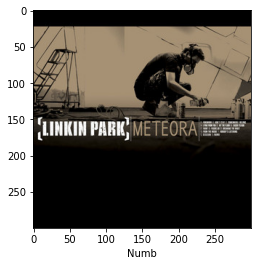

In [0]:
import matplotlib.pyplot as plt
from skimage import io

nome_musica = 'Linkin Park - Numb'
id = projection_kmeans\
          .filter(projection_kmeans.artist_song == nome_musica)\
          .select('id').collect()[0][0]

track = sp.track(id)

url = track["album"]["images"][1]["url"]
name = track["name"]

image = io.imread(url)
plt.imshow(image)
plt.xlabel(name, fontsize =10 )
plt.show()


In [0]:
import matplotlib.pyplot as plt
from skimage import io

def visualize_songs(name, url):
    plt.figure(figsize=(15, 10))
    columns = 5
    for i, u in enumerate(url):
        ax = plt.subplot(len(url) // columns + 1, columns, i + 1)
        image = io.imread(u)
        plt.imshow(image)
        ax.get_yaxis().set_visible(False)
        plt.xticks(color='w', fontsize=0.1)
        plt.yticks(color='w', fontsize=0.1)
        plt.xlabel(name[i], fontsize=10)
        plt.tight_layout(h_pad=0.7, w_pad=0)
        plt.subplots_adjust(wspace=None, hspace=None)
        plt.grid(visible=None)
    plt.show()

In [0]:
# Supondo que você já tenha a lista de IDs de músicas
playlist_id = df_recomendada.select('id').collect()

name = []
url = []
for i in playlist_id:
    track = sp.track(i[0])  # Acessando o ID da música
    url.append(track["album"]["images"][1]["url"])  # Coletando a URL da imagem
    name.append(track["name"])  # Coletando o nome da música

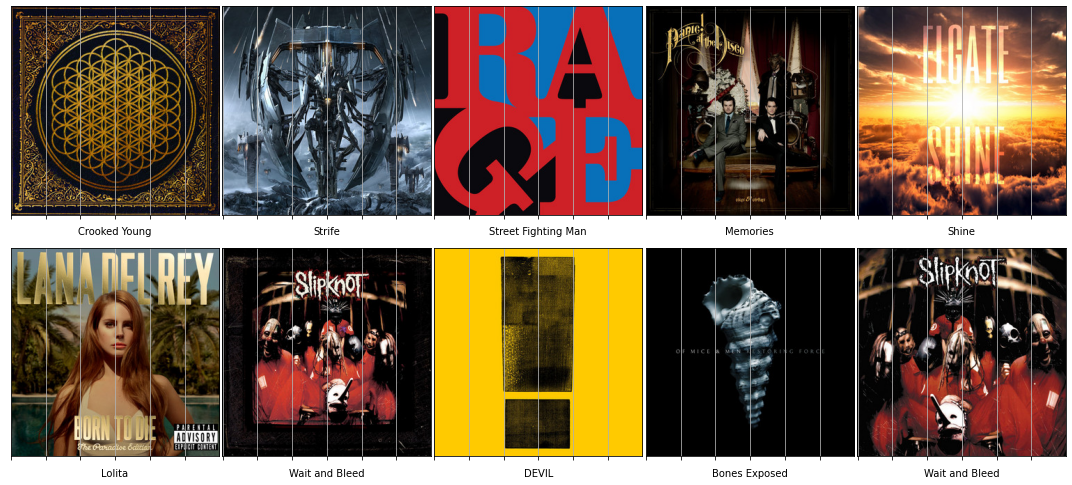

In [0]:
visualize_songs(name,url)